**Step 1: Install libraries**

In [1]:
!pip install torch torchvision -q
!pip install pandas numpy scikit-learn Pillow matplotlib -q

**Step 2: Imports**

In [2]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torchvision import transforms, models

from PIL import Image, ImageDraw

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

**Step 3: Get the dataset (tabular + images)**

In [3]:
# California Housing dataset — built into scikit-learn, no download/API key needed
# Contains median house prices + features like income, rooms, location, etc.
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Rename target column for clarity
df = df.rename(columns={"MedHouseVal": "price"})

# Use a manageable subset (full dataset is 20k+ rows — 2000 keeps image generation fast)
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(2000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


**Step 4: Generate a synthetic house image for every row, correlated with price**

In [5]:
os.makedirs("house_images", exist_ok=True)  # folder to store generated images

def generate_house_image(price, income, rooms, image_id, folder="house_images"):
    """
    Creates a simple synthetic house image where visual properties
    (size of house, color richness, number of windows) scale with price —
    giving the CNN genuine visual signal to learn from.
    """
    img_size = 128
    img = Image.new("RGB", (img_size, img_size), color=(200, 220, 255))  # sky background
    draw = ImageDraw.Draw(img)

    # Normalize price to a 0-1 scale to control visual complexity
    price_norm = min(max(price / df["price"].max(), 0), 1)

    # House size scales with price (bigger house = higher price)
    house_width = int(60 + price_norm * 50)
    house_height = int(40 + price_norm * 40)
    x0 = (img_size - house_width) // 2
    y0 = img_size - house_height - 20

    # House color richness scales with price (more expensive = richer brick tone)
    r = int(120 + price_norm * 100)
    house_color = (r, 80, 60)
    draw.rectangle([x0, y0, x0 + house_width, y0 + house_height], fill=house_color)

    # Roof
    draw.polygon([
        (x0 - 10, y0), (x0 + house_width // 2, y0 - 30), (x0 + house_width + 10, y0)
    ], fill=(90, 40, 30))

    # Number of windows scales with rooms feature (more rooms = more windows)
    num_windows = int(min(max(rooms, 1), 6))
    window_size = 10
    for i in range(num_windows):
        wx = x0 + 10 + i * (house_width // max(num_windows, 1))
        wy = y0 + house_height // 3
        draw.rectangle([wx, wy, wx + window_size, wy + window_size], fill=(255, 255, 200))

    # Lawn
    draw.rectangle([0, img_size - 20, img_size, img_size], fill=(100, 180, 100))

    path = os.path.join(folder, f"{image_id}.jpg")
    img.save(path)
    return path

# Generate one image per row in df
image_paths = []
for idx, row in df.iterrows():
    path = generate_house_image(
        price=row["price"],
        income=row["MedInc"],
        rooms=row["AveRooms"],
        image_id=idx
    )
    image_paths.append(path)

df["image_path"] = image_paths
print("Generated", len(df), "synthetic house images.")

Generated 2000 synthetic house images.


**Step 5:  Preview a few generated images**

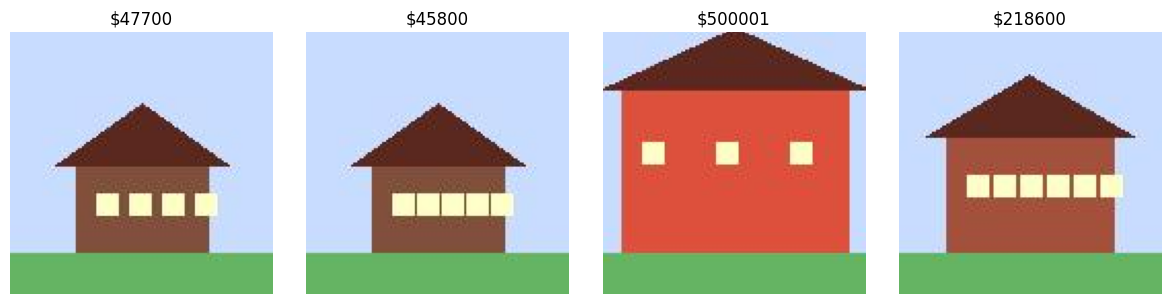

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    img = Image.open(df["image_path"].iloc[i])
    ax.imshow(img)
    ax.set_title(f"${df['price'].iloc[i]*100000:.0f}")  # price is in $100k units in this dataset
    ax.axis("off")
plt.tight_layout()
plt.show()

**Step 6: Train/test split**

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", len(train_df), "Test size:", len(test_df))

Train size: 1600 Test size: 400


**Step 7: Scale tabular features**

In [9]:
tabular_features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]

scaler = StandardScaler()
train_tabular = scaler.fit_transform(train_df[tabular_features])
test_tabular = scaler.transform(test_df[tabular_features])

**Step 8: Load pretrained CNN (ResNet18) for image feature extraction**

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()  # remove final classification layer, keep 512-dim feature output
resnet = resnet.to(device)
resnet.eval()

for param in resnet.parameters():
    param.requires_grad = False  # freeze weights, we're only extracting features

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


**Step 9: Extract CNN features from images**

In [11]:
def extract_image_features(paths, batch_size=32):
    all_features = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        batch_tensors = [image_transform(Image.open(p).convert("RGB")) for p in batch_paths]
        batch_tensor = torch.stack(batch_tensors).to(device)

        with torch.no_grad():
            features = resnet(batch_tensor)

        all_features.append(features.cpu().numpy())
        print(f"Processed {i + len(batch_paths)}/{len(paths)} images")

    return np.vstack(all_features)

train_image_features = extract_image_features(train_df["image_path"].tolist())
test_image_features = extract_image_features(test_df["image_path"].tolist())

print("Train image feature shape:", train_image_features.shape)  # (n, 512)

Processed 32/1600 images
Processed 64/1600 images
Processed 96/1600 images
Processed 128/1600 images
Processed 160/1600 images
Processed 192/1600 images
Processed 224/1600 images
Processed 256/1600 images
Processed 288/1600 images
Processed 320/1600 images
Processed 352/1600 images
Processed 384/1600 images
Processed 416/1600 images
Processed 448/1600 images
Processed 480/1600 images
Processed 512/1600 images
Processed 544/1600 images
Processed 576/1600 images
Processed 608/1600 images
Processed 640/1600 images
Processed 672/1600 images
Processed 704/1600 images
Processed 736/1600 images
Processed 768/1600 images
Processed 800/1600 images
Processed 832/1600 images
Processed 864/1600 images
Processed 896/1600 images
Processed 928/1600 images
Processed 960/1600 images
Processed 992/1600 images
Processed 1024/1600 images
Processed 1056/1600 images
Processed 1088/1600 images
Processed 1120/1600 images
Processed 1152/1600 images
Processed 1184/1600 images
Processed 1216/1600 images
Processe

**Step 10: Fuse image + tabular features**

In [13]:
X_train_fused = np.hstack([train_image_features, train_tabular])
X_test_fused = np.hstack([test_image_features, test_tabular])

y_train = train_df["price"].values
y_test = test_df["price"].values

print("Fused feature shape:", X_train_fused.shape)  # (n, 512 + 8)

Fused feature shape: (1600, 520)


**Step 11: Train regression model on fused features**

In [14]:
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train_fused, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

**Step 12: Evaluate with MAE and RMSE**

In [15]:
predictions = model.predict(X_test_fused)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Multimodal Model — MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Multimodal Model — MAE: 0.0226 | RMSE: 0.0475


**Step 13: Compare against tabular-only baseline (proves fusion adds value)**

In [16]:
baseline_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
baseline_model.fit(train_tabular, y_train)
baseline_preds = baseline_model.predict(test_tabular)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print(f"Tabular-only Baseline — MAE: {baseline_mae:.4f} | RMSE: {baseline_rmse:.4f}")
print(f"Multimodal Model       — MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Tabular-only Baseline — MAE: 0.3943 | RMSE: 0.5716
Multimodal Model       — MAE: 0.0226 | RMSE: 0.0475


**Step 14: Visualize predictions vs actual**

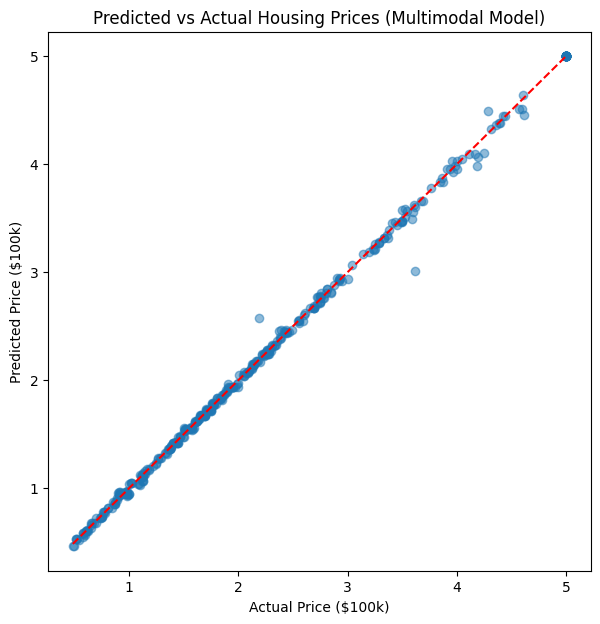

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.title("Predicted vs Actual Housing Prices (Multimodal Model)")
plt.show()